## Implementation of the ANN Using the Fashion MNIST Dataset

In [126]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [127]:
"""Setting the Random Seeds for the Reproducability"""
torch.manual_seed(42)

## Importing the Dataset

In [128]:
df = pd.read_csv("fmnist_small.csv")

In [129]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


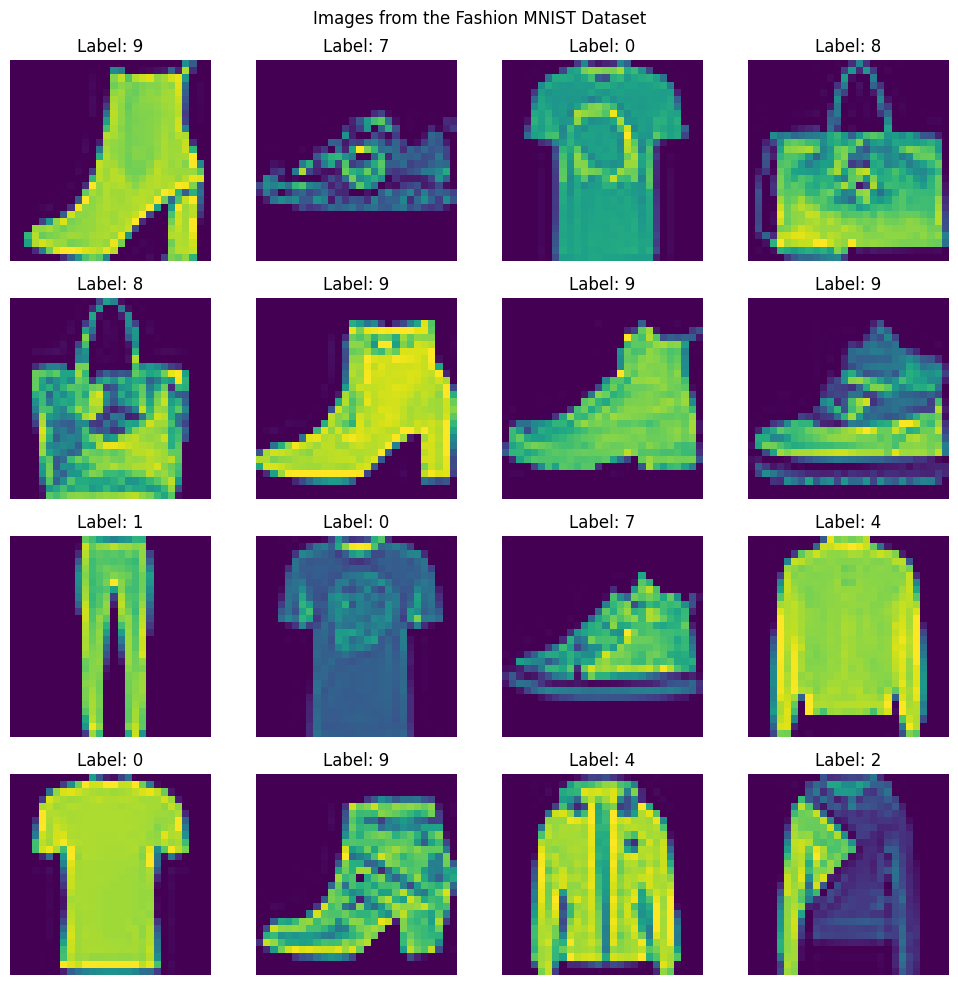

In [130]:
fig,axes = plt.subplots(4,4,figsize = (10,10))
fig.suptitle("Images from the Fashion MNIST Dataset")

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label: {df.iloc[i,0]}")

plt.tight_layout()
plt.show()

In [131]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [132]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [133]:
X_train.shape

(4800, 784)

In [134]:
X_train = X_train/255.0

In [135]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [136]:
y_train

array([7, 6, 7, ..., 0, 8, 6])

## Implementing the Model

In [137]:
from re import L
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype = torch.float32)
    self.labels = torch.tensor(labels,dtype = torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]


In [138]:
train_dataset = CustomDataset(X_train,y_train)

In [139]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [140]:
test_dataset = CustomDataset(X_test,y_test)

In [141]:
batch_size = 32
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
"""During the Testing Phase Shuffling is kept False"""
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

## Neural Network

In [142]:
class MyNeuralNetwork(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    """ By Default,The Last Layer Consists of the SoftMax Activation Function"""
    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,X):
    return self.model(X)

In [143]:
epochs = 100
learning_rate = 0.1

#### Initializing the Model

In [144]:
model = MyNeuralNetwork(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr = learning_rate)

In [145]:
print(f"Total Number of Batches :{len(train_loader)}")

Total Number of Batches :150


In [146]:
"""Training Loop"""

for epoch in range(epochs):

  total_epoch_loss = 0.0

  for batch_features,batch_labels in train_loader:
    outputs = model(batch_features)
    loss = criterion(outputs,batch_labels)

    """Before Calculating the Backward Propagation We need to CLear the Gradients"""
    optimizer.zero_grad()
    loss.backward()

    """To Update the Gradients we use 'optimizer.atep()' """
    optimizer.step()


    total_epoch_loss += loss.item()

  print(f"Epoch: {epoch+1}/{epochs}, Loss: {total_epoch_loss/len(train_loader)}")

Epoch: 1/100, Loss: 1.3216368440786999
Epoch: 2/100, Loss: 0.7793365436792373
Epoch: 3/100, Loss: 0.6427524652083715
Epoch: 4/100, Loss: 0.5751657336950302
Epoch: 5/100, Loss: 0.528180201848348
Epoch: 6/100, Loss: 0.49528750121593473
Epoch: 7/100, Loss: 0.4602432996034622
Epoch: 8/100, Loss: 0.4359459094206492
Epoch: 9/100, Loss: 0.41829214423894884
Epoch: 10/100, Loss: 0.3984092291692893
Epoch: 11/100, Loss: 0.3850264506538709
Epoch: 12/100, Loss: 0.3722685620188713
Epoch: 13/100, Loss: 0.3477362078428268
Epoch: 14/100, Loss: 0.3467242218057315
Epoch: 15/100, Loss: 0.3138812760512034
Epoch: 16/100, Loss: 0.3126461291313171
Epoch: 17/100, Loss: 0.29552092105150224
Epoch: 18/100, Loss: 0.2857150869568189
Epoch: 19/100, Loss: 0.27084775785605114
Epoch: 20/100, Loss: 0.26237100958824155
Epoch: 21/100, Loss: 0.25756089876095456
Epoch: 22/100, Loss: 0.24232648963729542
Epoch: 23/100, Loss: 0.23957946779827277
Epoch: 24/100, Loss: 0.2261324493587017
Epoch: 25/100, Loss: 0.2233684351791938
Ep

In [147]:
model.eval()

MyNeuralNetwork(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

## Evaluation

In [148]:
total = 0
correct = 0
with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    outputs = model(batch_features)
    _, predicted = torch.max(outputs,1)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()
print(f"Accuracy : {correct/total}")

Accuracy : 0.7883333333333333
